# Test Results Summary

整合各模型在測試集上的預測結果，計算並比較主要指標（ROC-AUC、PR-AUC、Brier、ECE），以及畫出 ROC / PR / calibration 圖。

In [1]:
import os, sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.metrics import expected_calibration_error


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)

from src.metrics import expected_calibration_error

plt.style.use('seaborn-v0_8-darkgrid')

outputs_dir = os.path.join(repo_root, "outputs")

model_files = {
    "Logistic (Baseline, GICS)": os.path.join(outputs_dir, "logistic_baseline", "predictions_test.csv"),
    "Logistic (No GICS)": os.path.join(outputs_dir, "logistic_baseline_no_gics", "predictions_test.csv"),
    "Random Forest": os.path.join(outputs_dir, "rf_model", "predictions_test.csv"),
    "XGBoost": os.path.join(outputs_dir, "xgboost_model", "predictions_test.csv"),
    "SVM": os.path.join(outputs_dir, "svm_model", "predictions_test.csv"),
    "Neural Network": os.path.join(outputs_dir, "nn_model", "predictions_test.csv"),
    "Gradient Boosting (gb_model)": os.path.join(outputs_dir, "gb_model", "predictions_test.csv"),
}

rows = []
model_curves = {}

for name, path in model_files.items():
    if not os.path.exists(path):
        print(f"[WARN] File not found for {name}: {path}")
        continue

    df = pd.read_csv(path)
    y_true = df["y_true"].values
    if "p_platt" in df.columns:
        y_prob = df["p_platt"].values
        prob_source = "p_platt"
    elif "p_isotonic" in df.columns:
        y_prob = df["p_isotonic"].values
        prob_source = "p_isotonic"
    else:
        y_prob = df["p_raw"].values
        prob_source = "p_raw"

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    model_curves[name] = {"fpr": fpr, "tpr": tpr, "prec": prec, "rec": rec}

    rows.append(
        {
            "model": name,
            "prob_source": prob_source,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "brier": brier,
            "ece": ece,
        }
    )

results = pd.DataFrame(rows)
if results.empty:
    print("No prediction files found. Please run the model notebooks to generate predictions_test.csv under outputs/.")
else:
    results = results.set_index("model")
    display(results.sort_values("pr_auc", ascending=False).round(4))

,prob_source,roc_auc,pr_auc,brier,ece
model,,,,,
XGBoost,p_platt,0.8222,0.6864,0.1499,0.0638
Gradient Boosting (gb_model),p_platt,0.8173,0.6840,0.1471,0.0622
Neural Network,p_platt,0.8154,0.6674,0.1553,0.0634
Random Forest,p_platt,0.8133,0.6662,0.1503,0.0571
"Logistic (Baseline, GICS)",p_platt,0.8018,0.6542,0.1575,0.0633
Logistic (No GICS),p_platt,0.7920,0.6533,0.1589,0.0681
SVM,p_platt,0.7684,0.5538,0.1750,0.0662


In [9]:
import os, json
import numpy as np
import pandas as pd

# 專案根目錄 & outputs 目錄（從 result_plots/ 往上一層）
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
outputs_dir = os.path.join(repo_root, "outputs")

models = [
    ("Logistic Regression",           "Ratios + GICS",         "logistic_baseline"),
    ("Logistic Regression",           "Ratios (no GICS)",      "logistic_baseline_no_gics"),
    ("Random Forest",                 "Ratios + GICS",         "rf_model"),
    ("XGBoost",                       "Ratios + GICS",         "xgboost_model"),
    ("SVM (RBF kernel)",              "Ratios + GICS",         "svm_model"),
    ("Neural Network (MLP)",          "Ratios + GICS",         "nn_model"),
    ("Gradient Boosting (gb_model)", "Ratios + GICS",         "gb_model"),
]

rows = []
for ml_method, feature, subdir in models:
    path = os.path.join(outputs_dir, subdir, "metrics_summary.json")
    if not os.path.exists(path):
        print(f"[WARN] metrics_summary.json not found for {ml_method}: {path}")
        continue

    with open(path, "r", encoding="utf-8") as f:
        ms = json.load(f)

    # 用 raw 的結果當 test 指標
    m_raw = ms["raw"]

    rows.append({
        "ML_method":        ml_method,
        "Feature":          feature,
        "train-AUC":        np.nan,  # 目前沒存 train，先留空
        "train-PRAUC":      np.nan,
        "train-precision":  np.nan,
        "train-recall":     np.nan,
        "train-F1-score":   np.nan,
        "test-AUC":         m_raw["roc_auc"],
        "test-PRAUC":       m_raw["pr_auc"],
        "test-precision":   m_raw["precision"],
        "test-recall":      m_raw["recall"],
        "test-F1-score":    m_raw["f1"],
    })

results_detailed = pd.DataFrame(rows)

if results_detailed.empty:
    print("No metrics_summary.json found under outputs/*/. 請先跑各模型產生結果。")
else:
    cols = [
        "ML_method", "Feature",
        "train-AUC", "train-PRAUC", "train-precision", "train-recall", "train-F1-score",
        "test-AUC", "test-PRAUC", "test-precision", "test-recall", "test-F1-score",
    ]
    results_detailed = results_detailed[cols]
    display(results_detailed.round(4))


,ML_method,Feature,train-AUC,train-PRAUC,train-precision,train-recall,train-F1-score,test-AUC,test-PRAUC,test-precision,test-recall,test-F1-score
0,Logistic Regression,Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.8018,0.6542,0.5728,0.6592,0.6130
1,Logistic Regression,Ratios (no GICS),NaN,NaN,NaN,NaN,NaN,0.7920,0.6533,0.5907,0.6369,0.6129
2,Random Forest,Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.8133,0.6662,0.5980,0.6816,0.6371
3,XGBoost,Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.8222,0.6864,0.5593,0.7374,0.6361
4,SVM (RBF kernel),Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.7684,0.5538,0.5082,0.6927,0.5863
5,Neural Network (MLP),Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.8154,0.6674,0.5537,0.7486,0.6366
6,Gradient Boosting (gb_model),Ratios + GICS,NaN,NaN,NaN,NaN,NaN,0.8173,0.6840,0.5799,0.7095,0.6382


## ROC / PR Curves

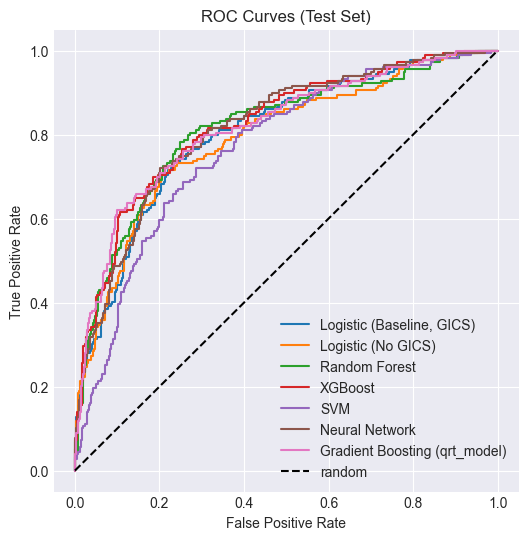

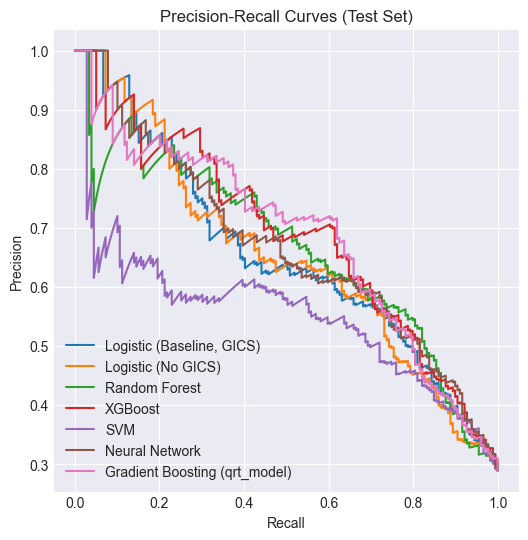

In [3]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 6))
for name, curves in model_curves.items():
    ax.plot(curves["fpr"], curves["tpr"], label=f"{name}")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Test Set)")
ax.legend(loc="lower right")
plt.show()

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(6, 6))
for name, curves in model_curves.items():
    ax.plot(curves["rec"], curves["prec"], label=f"{name}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (Test Set)")
ax.legend(loc="lower left")
plt.show()

## Calibration (Reliability) Curves

這裡示範畫其中幾個模型的 calibration 曲線（使用各模型選定的機率輸出欄位）。

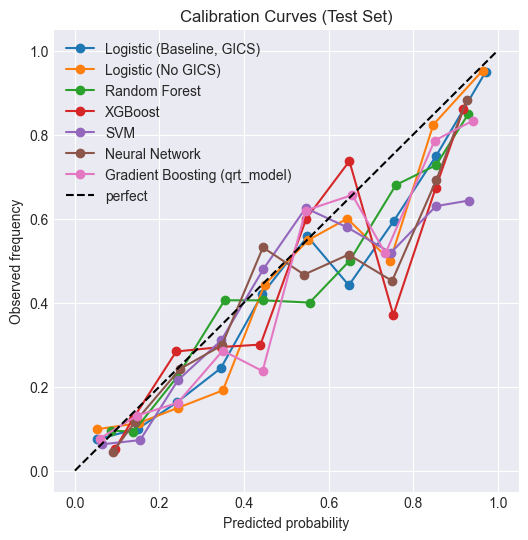

In [4]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))

for name, path in model_files.items():
    if name not in model_curves:
        continue
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    y_true = df["y_true"].values
    if "p_platt" in df.columns:
        y_prob = df["p_platt"].values
    elif "p_isotonic" in df.columns:
        y_prob = df["p_isotonic"].values
    else:
        y_prob = df["p_raw"].values

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", label="perfect")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Calibration Curves (Test Set)")
ax.legend(loc="best")
plt.show()